In [99]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from bct.algorithms.clustering import clustering_coef_wu
from bct.utils.other import threshold_proportional
from itertools import combinations
from scipy.sparse.csgraph import shortest_path, laplacian
from scipy.linalg import eigh
from scipy.io import mmread, loadmat
from scipy.spatial.distance import cdist
from small_world_propensity import SWP, characteristic_path_length, clustering_coefficient_bct, make_lattice_null

### Lattice formula idea:

Based on Figure 3, they're using a ring lattice, where the inner "core" has the smallest distances and therefore the highest edge weights.

Need to calculate the radius, r, of the lattice. Not clear how exactly to do this, but it's basically average degree or density, and supplementals say they're preserving the number of edges. So something like this:

    N = adj.shape[0]
    upper = np.triu(adj, k=1)
    E = np.count_nonzero(upper)
    r = int(np.round(E/N))

In [81]:
# Read in C. elegans and convert to adjacency matrix
elegans = pd.read_excel('NeuronConnect_C_elegans.xls')
elegans['weight'] = elegans['Nbr']
G = nx.from_pandas_edgelist(df=elegans, source='Neuron 1', target='Neuron 2', edge_attr='weight')
elegans_adj = nx.adjacency_matrix(G).toarray()

# Read in HCP SC and FC for one subject
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')

In [59]:
def make_lattice_null(adj):
    """
    Latticizes an inputted network. This is taken from Results: Generating Weighted 
    Small-World Networks, and Figure 3. In the Supplementals, they say that they use 
    Euclidean distance, but that requires some knowledge of where the nodes are in space. 
    I have some idea of how to get the Euclidean distances by using 
    nilearn.plotting.find_parcellation_cut_coords, but that requires having a .nii file, and,
    most importantly, they don't describe using Euclidean distance in the main text.

    This instead creates a circulant graph using the radius of the observed network. It maintains
    the number of edges and the edge weight distribution, distributing higher weights to edges
    with shorter distances around the ring.
    
    """
    Makes lattice null graph with the same number of edges and weight distribution as the input graph. 
    The highest weights are distributed to the nodes with shortest distance.

    Inputs
    ---
    adj  :  Weighted, undirected adjacency matrix.
           

    Returns
    ---
    lattice_null : Lattice null graph adjacency matrix. 

    
    """

    adj = adj.astype(float)
    adj = (adj + adj.T) / 2
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    G = nx.Graph(adj)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    N = adj.shape[0]

    # Calculate the observed radius
    upper = np.triu(adj, k=1)
    E = np.count_nonzero(upper)
    r = int(np.round(E/N))
    
    # Extract upper triangle edges and their weights
    rows, cols = np.triu_indices(N, k=1)
    weights = adj[rows, cols]
    # Sort in descending order
    weights_sorted = np.sort(weights)[::-1]
    
    node_order = np.arange(N)
    # Create circular lattice using radius,r, and N
    lattice_graph = nx.circulant_graph(n=N, offsets=range(1, r+1))
    # Get edges and compute distances
    lattice_edges = list(lattice_graph.edges())
    # Calculate circular distances for assigning weights
    lattice_distances = []
    for i, j in lattice_edges:
        # Minimum distance around the ring
        dist = min(abs(i - j), N - abs(i - j))
        lattice_distances.append(dist)

    # Sort distances; shorter distances get higher weights
    sorted_indices = np.argsort(lattice_distances)
    sorted_edges = [lattice_edges[idx] for idx in sorted_indices]

    # Assign weights
    lattice_adj = np.zeros((N, N))
    num_lattice_edges = len(sorted_edges)
    num_obs_edges = len(weights)

    # Check and handle edge count mismatches
    if num_lattice_edges != num_obs_edges:
        # Trim or pad
        num_assign = min(num_lattice_edges, num_obs_edges)
        assigned_weights = weights_sorted[:num_assign]
    else:
        num_assign = num_lattice_edges
        assigned_weights = weights_sorted

    for idx, (i, j) in enumerate(sorted_edges[:num_assign]):
        lattice_adj[i, j] = assigned_weights[idx]
        lattice_adj[j, i] = assigned_weights[idx]

    inverse_order = np.argsort(node_order)
    lattice_adj = lattice_adj[inverse_order][:, inverse_order]

    return lattice_adj



In [3]:
def characteristic_path_length2(adj):
    """
    Calculates the characteristic path length, L. Since this is for weighted networks, 
    the distance between two nodes is defined as the inverse of the weight of the edge 
    connecting the nodes, hence, d_ij = 1/w_ij.
    This uses scipy.sparse.csgraph.shortest_path to find the shortest paths.

    Inputs
    ---
    adj : Weighted, undirected graph adjacency matrix.

    Returns
    ---
    L   : Characteristic path length for inputted network.
    
    """
    # All floats
    adj = adj.astype(float)
    # Ensure symmetric
    adj = (adj + adj.T) / 2
    
    # Number of nodes
    N = adj.shape[0]
    # Create distance matrix by replacing edge weights with d_ij = 1/w_ij
    with np.errstate(divide='ignore'):
        dist = np.where(adj > 0, 1.0 / adj, np.inf)
    np.fill_diagonal(dist, 0.0)
    dist_matrix = shortest_path(dist, method='auto', directed=False)

    inv_sum = 0

    for i in range(N):
        for j in range(N):
            if i != j:
                if np.isfinite(dist_matrix[i, j]):
                    inv_sum += 1.0 / dist_matrix[i, j]
    total_pairs = N * (N - 1)
    
    L = total_pairs / inv_sum

    return L, dist_matrix

In [106]:
def make_lattice_null(adj):
    """
    Generates a regular matrix with weights from the original network. 
    The radius r is automatically calculated from the network density.
    
    Parameters:
    -----------
    adj : Weighted, undirected adjacency matrix.
        
    Returns:
    --------
    lattice_null : Lattice null graph adjacency matrix.
    
    """
    # Ensure symmetry
    adj = (adj + adj.T) / 2
    n = len(adj)
    
    # Calculate r from network density
    # Count edges in upper triangle (excluding diagonal)
    upper_tri = np.triu(adj, k=1)
    E = np.count_nonzero(upper_tri)
    r = int(np.ceil(E / n))
    
    # Get all weights from upper triangle (including zeros)
    full_upper = np.triu(adj)
    all_weights = full_upper.flatten()
    
    # Sort in descending order
    sorted_weights = np.sort(all_weights)[::-1]
    
    # Calculate number of columns needed
    num_els = int(np.ceil(n / 2))
    
    # Pad or trim to reach required size: n * num_els
    required_size = n * num_els
    if len(sorted_weights) < required_size:
        sorted_weights = np.pad(sorted_weights, (0, required_size - len(sorted_weights)), 
                               constant_values=0)
    else:
        sorted_weights = sorted_weights[:required_size]
    
    # Reshape to matrix (n rows, num_els cols) using column-major order (MATLAB style)
    weight_matrix = sorted_weights.reshape(n, num_els, order='F')
    
    # Initialize output matrix
    lattice_null = np.zeros((n, n))
    
    # Assign weights to create regular network
    # For each node (origin)
    for node in range(n):
        # For each distance ring from 1 to r
        for dist in range(1, r + 1):            
            # Convert to 0-indexing
            col_idx = dist - 1  
            
            # Find available (non-zero) weights in this column
            available = np.where(weight_matrix[:, col_idx] != 0)[0]
            
            if len(available) > 0:
                # Randomly select a weight from available ones
                chosen_row = np.random.choice(available)
                weight = weight_matrix[chosen_row, col_idx]
                
                # Calculate target node at distance 'dist' around the ring
                target = (node + dist) % n
                
                # Assign symmetrically
                lattice_null[node, target] = weight
                lattice_null[target, node] = weight
                
                # Mark this weight as used (remove from pool)
                weight_matrix[chosen_row, col_idx] = 0
    
    return lattice_null

In [107]:
latt1 = regular_matrix_generator(sc)
latt2 = regular_matrix_generator(sc)

<Axes: >

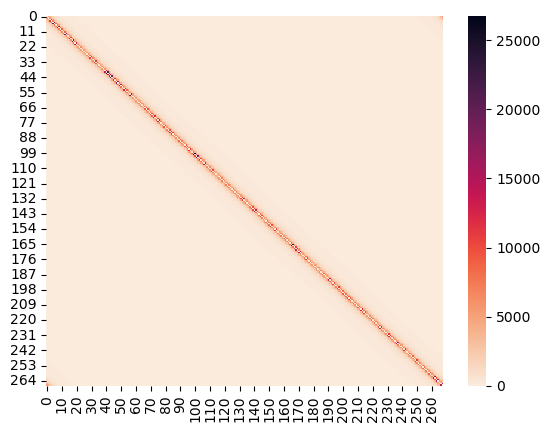

In [108]:
sns.heatmap(latt1, cmap='rocket_r')

In [ ]:
def characteristic_path_length(adj):
    """
    Calculates the characteristic path length, L. Since this is for weighted networks, 
    the distance between two nodes is defined as the inverse of the weight of the edge 
    connecting the nodes, hence, d_ij = 1/w_ij.
    This uses scipy.sparse.csgraph.shortest_path to find the shortest paths.

    Inputs
    ---
    adj : Weighted, undirected graph adjacency matrix.

    Returns
    ---
    L   : Characteristic path length for inputted network.
    
    """
    # All floats
    adj = adj.astype(float)
    # Ensure symmetric
    adj = (adj + adj.T) / 2
    G = nx.Graph(adj)
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    # Number of nodes
    N = adj.shape[0]
    # Create distance matrix by replacing edge weights with d_ij = 1/w_ij
    with np.errstate(divide='ignore'):
        dist = np.where(adj > 0, 1.0 / adj, np.inf)
    np.fill_diagonal(dist, 0.0)
    dist = shortest_path(dist, method='auto', directed=False)
    
    L = dist.sum() / (N * (N - 1))

    return L

In [61]:
t = threshold_proportional(fc, 0.20)
nx.is_connected(nx.Graph(t))

False

In [62]:
adj = t.copy()
N = adj.shape[0]
with np.errstate(divide='ignore'):
        dist = np.where(adj > 0, 1.0 / adj, np.inf)
np.fill_diagonal(dist, 0.0)
#G = nx.Graph(dist)
#paths = nx.all_shortest_paths(G)
paths = shortest_path(dist, method='auto', directed=False)
for i in range(N):
    for j in range(N):
        if i != j:
            if np.isinf(paths[i, j]):
                paths[i, j] = 0
L = paths.sum() / (N * (N - 1))
print(L)

3.2081173044621814


In [16]:
np.isnan(paths).sum()

np.int64(0)

In [12]:
adj = sc.copy()
N = adj.shape[0]
#G = nx.Graph(adj)
"""
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G0 = G.subgraph(largest_cc)
    adj = nx.adjacency_matrix(G0).toarray()
"""
with np.errstate(divide='ignore'):
        dist = np.where(adj > 0, 1.0 / adj, 0)
G = nx.Graph(dist)
paths = nx.average_shortest_path_length(G, weight='weight')
print(paths)

0.0013217206648844819


In [62]:
paths

0.0013217206648844819

In [53]:
foo = nx.adjacency_matrix(G).toarray()

In [54]:
l = characteristic_path_length(t)
print(l)

3.608824583138448


In [82]:
c = clustering_coefficient_bct(fc)
print(c)

0.23188724209466913


In [83]:
thresholds = np.linspace(0.1, 0.9, 9)
for t in thresholds:
    fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')
    mat = threshold_proportional(fc, t)
    c = clustering_coefficient_bct(mat)
    print(f'threshold {t}: c={c}')

threshold 0.1: c=0.3724355975917689
threshold 0.2: c=0.35775884845360056
threshold 0.30000000000000004: c=0.34174450407071705
threshold 0.4: c=0.3302707199969742
threshold 0.5: c=0.3210279035028297
threshold 0.6: c=0.3107113369331627
threshold 0.7000000000000001: c=0.3021467821709589
threshold 0.8: c=0.2922090137734247
threshold 0.9: c=0.2770313265135597


<Axes: >

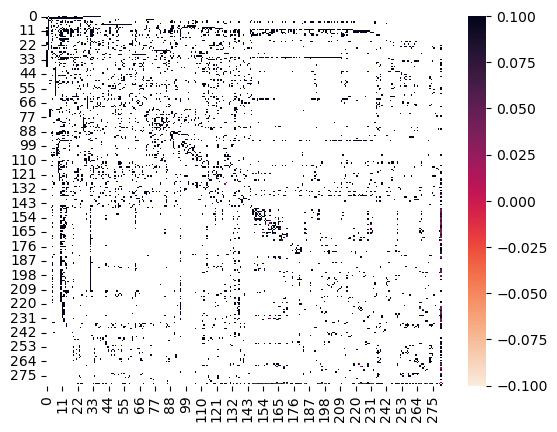

In [54]:
sns.heatmap(foo, cmap='rocket_r')

In [26]:
L = np.mean(dist)

In [27]:
L

np.float64(0.04147805999912602)

In [9]:
np.isnan(dist).sum()

np.int64(0)

In [43]:
adj = sc.copy()
N = adj.shape[0]
# Calculate the appropriate radius
upper = np.triu(adj, k=1)
E = np.count_nonzero(upper)
r = int(np.round(E/N))
grid = nx.circulant_graph(n=N, offsets=range(1, r+1))

In [45]:
nx.write_graphml(grid, 'grid.graphml')

In [48]:
r*2

194

In [49]:
N = adj.shape[0]
upper = np.triu(adj, k=1)
E_obs = np.count_nonzero(upper)
expected_edges = N * 97

print(f"N = {N}")
print(f"Observed edges: {E_obs}")
print(f"Expected edges (N * r): {expected_edges}")
print(f"Difference: {E_obs - expected_edges}")
print(f"Relative error: {(E_obs - expected_edges)/E_obs:.2%}")

N = 268
Observed edges: 25915
Expected edges (N * r): 25996
Difference: -81
Relative error: -0.31%


In [50]:
N/2

134.0

In [51]:
avg_degree_obs = 2 * E_obs / N
avg_degree_lattice = 2 * r

print(f"Observed average degree: {avg_degree_obs:.2f}")
print(f"Lattice average degree: {avg_degree_lattice:.2f}")

Observed average degree: 193.40
Lattice average degree: 194.00


In [52]:
np.mean(list(dict(nx.Graph(sc).degree())))

np.float64(133.5)

In [20]:
spis = ['additive_noise', 'barycenter', 'coherence_mag', 'cointegration', 'covariance',
        'directed_info', 'granger', 'integrated_info', 'itakura', 'phase_lag',
        'phase_slope_spectral', 'phase_slope_wavelet', 'power_env_corr', 'transfer_entropy']

spi_dir = '/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/'
sc_dir = '/home/gbz6qn/Documents/research/data/hcp_shen_sc/'
subs = os.listdir(spi_dir)

In [64]:
results_sc = {'SWP': [],
              'delta_C': [],
              'delta_L': []
             }
disconnected = []
for i, sub in tqdm(enumerate(subs)):
    sc_path = os.path.join(sc_dir, f'sub-{sub}_parc-shen268_tract-prob_sc.npy')
    try:
        sc = np.load(sc_path)
        G = nx.Graph(sc)
        if not nx.is_connected(G):
            disconnected.append(sub)
    except:
        pass
    swp, delta_C, delta_L = SWP(sc)
    results_sc['SWP'].append(swp)
    results_sc['delta_C'].append(delta_C)
    results_sc['delta_L'].append(delta_L)
df = pd.DataFrame(results_sc, columns = results_sc.keys())
df.to_csv('sc_results.csv')

213it [02:51,  1.27it/s]

Graph is not fully connected.


338it [04:37,  1.22it/s]


In [66]:
swp, delta_C, delta_L = SWP(elegans_adj)

Graph is not fully connected.


In [67]:
swp

np.float64(0.6586812554438475)

In [23]:
cat = loadmat('cat.mat')['CIJctx']
macaque = loadmat('macaque71.mat')['CIJ']
elegans_binary = np.where(elegans_adj > 0, 1, 0)

In [24]:
SWP_m, delta_C_m, delta_L_m = SWP(macaque)
SWP_c, delta_C_c, delta_L_c = SWP(cat)
SWP_eb, delta_C_eb, delta_L_eb = SWP(elegans_binary)
SWP_e, delta_C_e, delta_L_e = SWP(elegans_adj)

Graph is not fully connected.
Graph is not fully connected.


In [25]:
sc_results = pd.read_csv('sc_results.csv', index_col='Unnamed: 0')
SWP_sc = np.mean(sc_results['SWP'])
delta_C_sc = np.mean(sc_results['delta_C'])
delta_L_sc = np.mean(sc_results['delta_L'])

In [37]:
SWP_cov = []
delta_C_cov = []
delta_L_cov = []
for sub in subs:
    fc_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    try:
        fc = np.load(fc_path)
    except:
        print(f'Sub {sub} failed')
        pass
    G = nx.Graph(np.abs(fc))
    G0 = nx.maximum_spanning_tree(G)
    adj = nx.adjacency_matrix(G0).toarray()

    swp, delta_C, delta_L = SWP(adj)
    SWP_cov.append(swp)
    delta_C_cov.append(delta_C)
    delta_L_cov.append(delta_L)


/sfs/gpfs/tardis/home/gbz6qn/Documents/PhD/Spring26/network_science/network-science-final/small_world_propensity.py:272: RuntimeWarning: invalid value encountered in scalar divide
  delta_C = (C_latt - C_obs) / (C_latt - C_rand)


In [46]:
SWP_fc = np.array(SWP_cov)
SWP_fc = np.mean(SWP_fc[~np.isnan(SWP_fc)])
delta_C_fc = np.array(delta_C_cov)
delta_C_fc = np.mean(delta_C_fc[~np.isnan(delta_C_fc)])
delta_L_fc = np.array(delta_L_cov)
delta_L_fc = np.mean(delta_L_fc[~np.isnan(delta_L_fc)])

In [44]:
SWP_fc

np.float64(0.952625779961353)

In [25]:
SWP_fc = np.mean(SWP_cov)
delta_C_fc = np.mean(delta_C_cov)
delta_L_fc = np.mean(delta_L_cov)
print(f'SWP: {SWP_fc}, delta_C: {delta_C_fc}, delta_L: {delta_L_fc}')

SWP: nan, delta_C: nan, delta_L: 0.066051006019364


In [53]:
sc = pd.DataFrame(data=[{
    'SWP': SWP_sc,
    'delta_C': delta_C_sc,
    'delta_L': delta_L_sc,
    'source': 'Human structural'
}])

cat = pd.DataFrame(data=[{
    'SWP': SWP_c,
    'delta_C': delta_C_c,
    'delta_L': delta_L_c,
    'source': 'Cat cortex'
}])

macaque = pd.DataFrame(data=[{
    'SWP': SWP_m,
    'delta_C': delta_C_m,
    'delta_L': delta_L_m,
    'source': 'Macaque'
}])

eb = pd.DataFrame(data=[{
    'SWP': SWP_eb,
    'delta_C': delta_C_eb,
    'delta_L': delta_L_eb,
    'source': 'C. elegans (binary)'
}])

e = pd.DataFrame(data=[{
    'SWP': SWP_e,
    'delta_C': delta_C_e,
    'delta_L': delta_L_e,
    'source': 'C. elegans (weighted)'
}])

fc = pd.DataFrame(data=[{
    'SWP': SWP_fc,
    'delta_C': delta_C_fc,
    'delta_L': delta_L_fc,
    'source': 'Human rs-fMRI'
}])

df = pd.concat([sc, fc, cat, eb, e, macaque])
#df = df.rename(columns={0: 'Human Structural', 1: 'Human rs-fMRI', 2: 'Cat cortex',
#                        3: 'C. elegans (binary)', 4: 'C. elegans (weighted)', 5: 'Macaque'})

In [28]:
df['source'] = ['Human structural', 'Human rs-fMRI', 'Cat cortex', 'C. elegans (binary)', 'C. elegans (weighted)', 'Macaque']
df

,SWP,delta_C,delta_L,source,alpha,deviation
0,0.886111,0.126916,0.095066,Human structural,0.642890,-0.181447
1,0.952626,0.000000,0.065975,Human rs-fMRI,1.570796,1.000000
2,0.793394,0.147372,0.252297,Cat cortex,1.042133,0.326885
3,0.609642,0.551977,0.008916,C. elegans (binary),0.016152,-0.979434
4,0.661502,0.478707,0.001313,C. elegans (weighted),0.002743,-0.996507
5,0.728342,0.357520,0.140625,Macaque,0.374747,-0.522858


In [27]:
df

,SWP,delta_C,delta_L,source,alpha,deviation
0,0.886111,0.126916,0.095066,NaN,0.642890,-0.181447
1,0.952626,0.000000,0.065975,NaN,1.570796,1.000000
2,0.793394,0.147372,0.252297,NaN,1.042133,0.326885
3,0.609642,0.551977,0.008916,NaN,0.016152,-0.979434
4,0.661502,0.478707,0.001313,NaN,0.002743,-0.996507
5,0.728342,0.357520,0.140625,NaN,0.374747,-0.522858


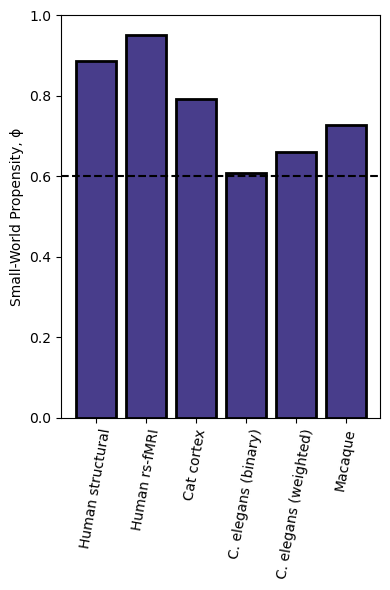

In [40]:
fig, ax = plt.subplots(figsize=(4, 6))
plt.bar(data=df,
       x='source',
       height='SWP',
       color='darkslateblue',
       linewidth=2,
       edgecolor='black')
plt.axhline(y=0.6, linestyle='--', color='black')
#plt.title('Reproduced SWP')
plt.ylabel('Small-World Propensity, ϕ')
ax.tick_params(axis='x', rotation=80, direction='out')
plt.tight_layout()
plt.savefig('swp_reproduction_v1.png')
plt.show()

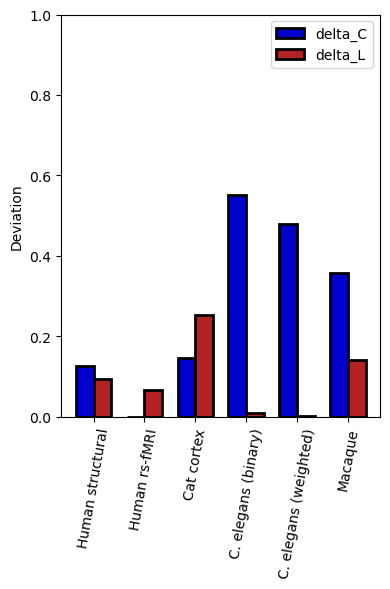

In [39]:
fig, ax = plt.subplots(figsize=(4, 6))
width = 0.35
x = np.arange(len(df['source']))
bars1 = ax.bar(x - width/2, df['delta_C'], width,
               label='delta_C', color='mediumblue',
               edgecolor='black', linewidth=2)
bars2 = ax.bar(x + width/2, df['delta_L'], width,
               label='delta_L', color='firebrick',
               edgecolor='black', linewidth=2)

ax.set_ylabel('Deviation')
#ax.set_title('ΔC and ΔL Comparison')
ax.set_xticks(x)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_xticklabels(df['source'])
ax.tick_params(axis='x', rotation=80, direction='out')
ax.legend()
plt.tight_layout()
plt.savefig('deviation_reproduction_v1.png')
plt.show()

deviation = $\frac{4\alpha}{\pi} - 1$, where $\alpha = tan^{-1}(\frac{\Delta_L}{\Delta_C})$

In [100]:
df['alpha'] = np.arctan(df['delta_L'] / df['delta_C'])
df['deviation'] = ((4 * df['alpha']) / np.pi) - 1

In [29]:
df.to_csv('results_combined_df.csv', index=False)

In [30]:
df = pd.read_csv('results_combined_df.csv')

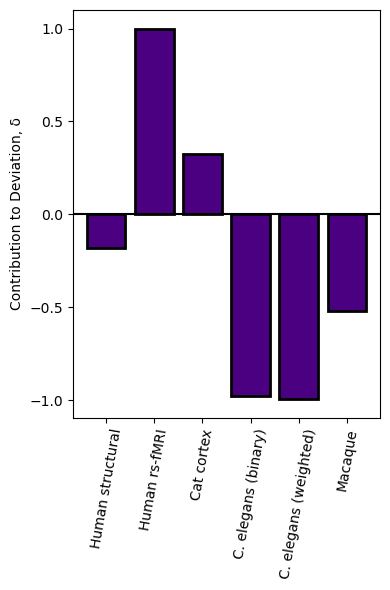

In [38]:
fig, ax = plt.subplots(figsize=(4, 6))
ax.bar(data=df,
       x='source',
       height='deviation',
       color='indigo',
       edgecolor='black',
       linewidth=2
      )
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.axhline(y=0, color='black', linestyle='-')
ax.tick_params(axis='x', rotation=80, direction='out')
plt.ylabel('Contribution to Deviation, δ')
plt.tight_layout()
plt.savefig('contribution_reproduction_v1.png')
plt.show()